In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [13]:
from langchain.chat_models import init_chat_model
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from langchain_core.tools import tool
from langgraph.prebuilt import tools_condition, ToolNode

from langgraph.graph import START, END, StateGraph
# llm= init_chat_model(
#     model="qwen3.6", 
#     model_provider="ollama",
#     temperature=0.3
# )




class State(TypedDict):
    messages: Annotated[list, add_messages]

#define tool here 
@tool("get_stock_price", description="Fetches the stock price for a given stock symbol")
def get_stock_price(stock_symbol: str) -> float:
    ''' Placeholder implementation for fetching stock price
        :param stock_symbol: The stock symbol to fetch the price for
        :return: The stock price as a float
    '''
    stock_prices = {
        "AAPL": 150.0,
        "GOOGL": 2800.0,
        "AMZN": 3400.0,
        "MSFT": 300.0
    }
    return stock_prices.get(stock_symbol.upper(), 0.0)

#prepare tools list available for chatbot to use
tools = [get_stock_price]

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0.7
)

#llm with tools binding
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State) -> State:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)
#add tool node
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot_node")
#add conditional edge to tool node
builder.add_conditional_edges("chatbot_node", tools_condition)
builder.add_edge("chatbot_node", END)
graph = builder.compile()




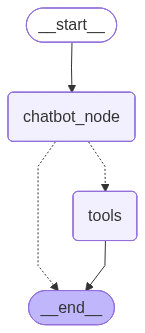

In [7]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
message = {"role": "user", "content": "i want to buy 10 shares of AAPL and 10 shares of GOOGL, what is the total price?"}
state = graph.invoke({"messages": [message]})

print(state["messages"][-1].content)

2800.0
